[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Loicsav/SalasOrtegaConde/blob/main/k-brazos/Softmax.ipynb)

# **Estudio comparativo de algoritmos softmax en un problema de k-armed bandit**

**Descripción**: Description: El experimento compara el rendimiento de algoritmos de ascenso del gradiante en un problema de k-armed bandit. 
* Se generan gráficas de recompensas promedio para cada algoritmo.
* Se generan gráficas de selecciones óptimas para cada algoritmo.
* Se generan gráficas de estadísticas de brazos para cada algoritmo.
* Se generan gráficas de arrepentimiento promedio para cada algoritmo.

**Asignatura**: Extensiones de Machine Learning, 2025/2026

**Autores**: 
* Alberto Ortega Pastor
* Manuel Salas Díaz
* Lola Conde Herrera

**Máster de Inteligencia Artificial**

**Facultad de Informática**

-----

## Preparación del entorno

Para poder realizar los experimentos, vamos a clonar el repositorio de github donde se encuentran todos los ficheros empleados en la experimentacion.

In [ ]:
!git clone https://github.com/Loicsav/SalasOrtegaConde.git
%cd SalasOrtegaConde/k-brazos

In [1]:
from typing import List

from src.algorithms import Algorithm, Softmax
from src.arms import ArmNormal, Bandit, ArmBernoulli, ArmBinomial
from src.plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret, boxplot_estimaciones_brazos

Ahora configuramos la semilla que se va emplear en todo el experimento para garantizar la reproducibilidad.

In [2]:
import os
import gc
import torch
import numpy as np
#import gymnasium as gym
# Configuración del dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Liberación de memoria para evitar problemas de consumo en GPU
gc.collect() # Ejecuta el recolector de basura de Python
torch.cuda.empty_cache() # Vacía la caché de memoria en GPU

# Depuración de errores en CUDA
os.environ['CUDA_LAUNCH_BLOCKING'] = '1' # Muestra errores de CUDA en el punto exacto donde ocurren

# Configuración de la semilla para reproducibilidad
seed = 123 # Se define una semilla fija

# Fijar la semilla en NumPy
np.random.seed(seed) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(seed) # Establece una instancia del generador de NumPy con la misma semilla

# Fijar la semilla en Python
os.environ['PYTHONHASHSEED'] = str(seed) # Evita variabilidad en hashing de Python

# Fijar la semilla en PyTorch
torch.manual_seed(seed) # Asegura resultados reproducibles en operaciones de PyTorch
if torch.cuda.is_available(): # Si hay GPU disponible
    torch.cuda.manual_seed(seed) # Fija la semilla para la GPU
    torch.backends.cudnn.deterministic = True # Hace las operaciones de CUDNN determinísticas
    torch.backends.cudnn.benchmark = False # Desactiva optimizaciones de CUDNN para evitar variabilidad

# Fijar la semilla en Gymnasium
#def make_env(env_name):
#    env = gym.make(env_name)
#    env.reset(seed=seed) # Establece la semilla en el entorno de Gymnasium
#    return env

# Ejemplo de creación de un entorno con semilla
env_name = "CartPole-v1" # Cambiar según el entorno deseado

Usando dispositivo: cpu


## Experimentos

Cada algoritmo se prueba en un problema de k-armed bandit durante un número fijo de pasos y ejecuciones. Después, se comparan sus resultados usando la recompensa media.

* Valores de tau:
    - tau: $0.5$, el algoritmo explota más que explora un brazo
    - tau: $1$, el algoritmo explora igual forma que explota un brazo
    - tau: $2$, el algoritmo explora más que explota un brazo

* Experimentos:
    - Experimento 1: Distribución Normal
    - Experimento 2: Distribución Bernoulli
    - Experimento 3: Distribución Binomial

Para un bandido de k brazos se ejecuta el algoritmo de SoftMax con diferentes valores de tau (0.5, 1 y 2) y se analiza cómo evoluciona su política durante 1000 pasos. Este proceso se repite 500 veces, es decir, se simula cada algoritmo 500 veces a lo largo de 1000 pasos. Finalmente, en cada paso se calcula el promedio de las recompensas obtenidas en todas las ejecuciones.

In [3]:
k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

El siguiente código sirve para realizar cada experimento, indicando el bandido inicializado, los algoritmos a emplear, el número de pasos por algoritmo y el número de repeticiones. Para cada algoritmo, se recogerán varias métricas:

* Número de veces que se ha elegido cada brazo
* Porcentage de elección del mejor brazo
* Valores de recompensas promedio estimados
* Valor de Regret acumulado

Una vez finalizado el experimento, se podrá emplear dichas métricas para generar gráficas con las que poder evaluar y comparar los algoritmos.

In [4]:
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    # Recopilar estadísticas de brazos para cada algoritmo
    arm_stats = []
    for algo in algorithms:
        arm_data = [
            {
                'arm': i + 1,  # Número del brazo (1 al k)
                'counts': 0.0,  # Número de veces seleccionado
                'values': 0.0,  # Recompensa promedio estimada
            }
            for i in range(algo.k)
        ]
        arm_stats.append(arm_data)

    # Recopilar todas las estimaciones finales de cada algoritmo en cada ejecución
    all_runs_data = []
    for algo in algorithms:
        all_runs_data.append([])

    # Recopilar el número de ejecuciones de cada brazo para cada algoritmo en cada ejecución
    all_runs_counts = []
    for algo in algorithms:
        all_runs_counts.append([])

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    regrets = np.zeros((len(algorithms), steps))  # Matriz para almacenar el regret acumulado.

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                regrets[idx, step] += (current_bandit.get_expected_value(optimal_arm) - reward) # Acumular el regret obtenido en la matriz regrets para el algoritmo idx en el paso step.

                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1
        for arms_algo, algo in zip(arm_stats, algorithms):
            for arm_data in arms_algo:
                i = arm_data["arm"] -1
                arm_data["counts"] = arm_data["counts"] + algo.counts[i]
                arm_data["values"] = arm_data["values"] + float(algo.values[i])
        for arm_values, algo in zip(all_runs_data, algorithms):
            lista = []
            for i in range(k):
                lista.append(algo.values[i])
            arm_values.append(lista)

        for arm_counts, algo in zip(all_runs_counts, algorithms):
            lista = []
            for i in range(k):
                lista.append(algo.counts[i])
            arm_counts.append(lista)


    rewards /= runs
    regrets /= runs
    optimal_selections /= runs
    
    # Recopilar estadísticas de brazos para cada algoritmo
    for arms_algo, algo in zip(arm_stats, algorithms):
            for arm_data in arms_algo:
                i = arm_data["arm"] -1
                arm_data["values"] = arm_data["values"]/runs
                arm_data["counts"] = int(arm_data["counts"]/runs)

    return rewards, optimal_selections, arm_stats, regrets, all_runs_data, all_runs_counts

### ``1. Experimento distribución Normal``

Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución normal. Se realizan 500 ejecuciones de 1000 pasos cada una. Se contrastan 3 algoritmos de Softmax.

In [5]:
# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [Softmax(k=k, tau=1), Softmax(k=k, tau=0.5), Softmax(k=k, tau=2)]

# Ejecutar el experimento y obtener las recompensas promedio, porcentaje de selecciones óptimas y estadísticas de brazos
rewards, optimal_selections, arm_stats, regrets, all_runs_data, all_runs_counts = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmNormal(mu=3.04, sigma=1.0), ArmNormal(mu=3.58, sigma=1.0), ArmNormal(mu=5.96, sigma=1.0), ArmNormal(mu=4.81, sigma=1.0), ArmNormal(mu=7.48, sigma=1.0), ArmNormal(mu=7.27, sigma=1.0), ArmNormal(mu=9.83, sigma=1.0), ArmNormal(mu=7.16, sigma=1.0), ArmNormal(mu=5.33, sigma=1.0), ArmNormal(mu=4.53, sigma=1.0)
Optimal arm: 7 with expected reward=9.83


#### **Visualización**

En esta apartado vamos a mostrar y analizar las diferentes gráficas generadas para el experimento del bandido de k-brazos con distribución normal. Las gráficas que se van mostrar son las siguientes:

* Evolución de la recompensa promedio durante el experimento
* Evolución del porcentaje de la selección del mejor brazo
* Número de veces que se ha seleccionado cada brazo en el experimento
* Boxplots de las estimaciones de recompensa por cada brazo.
* Evolución del arrepentimiento durante el experimento

Para empezar, vamos a analizar de la evolución de la recompensa promedio


##### **1.1 Análisis Recompensa promedio**

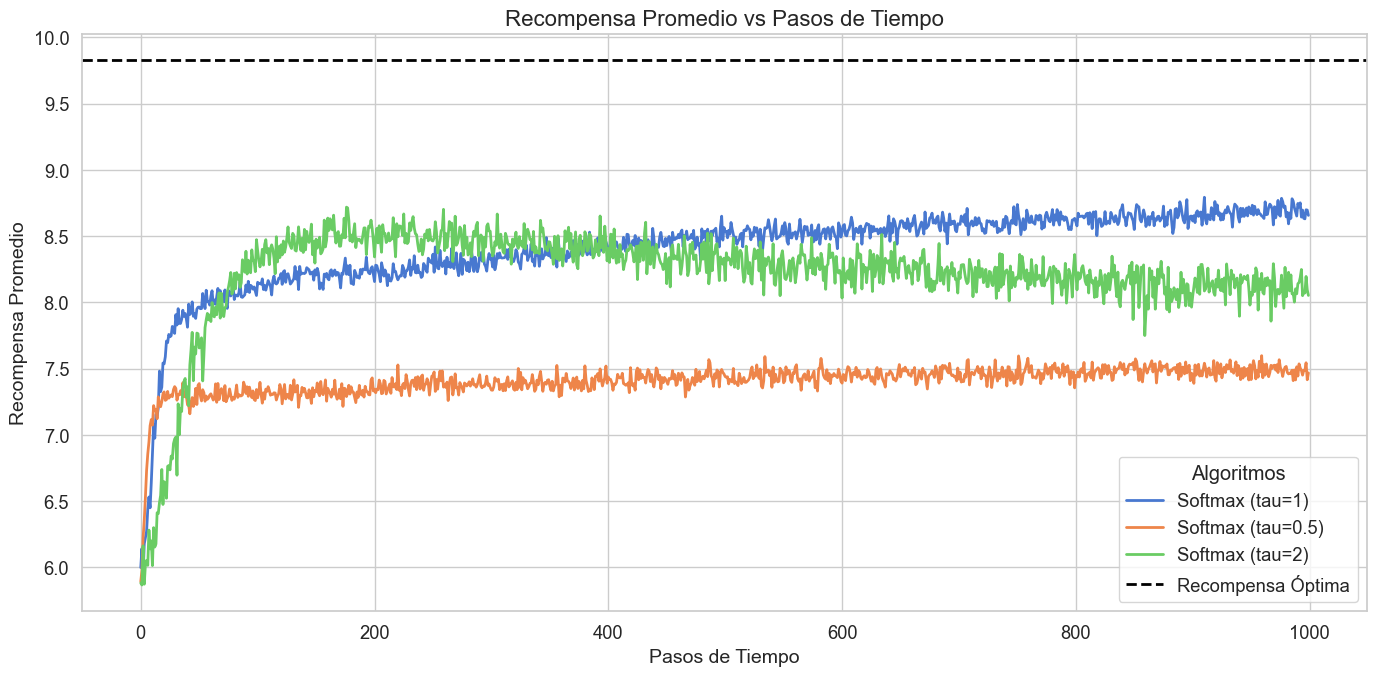

In [6]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms, optimal_reward=bandit.get_expected_value(bandit.optimal_arm))

En el grafíco anterior podemos apreciar la **Recompensa Promedio vs Pasos de Tiempo** aplicado para los algoritmos de Softmax con distintos valores de tau. En este gráfico representamos los steps en comparación con la recompensa promedio que se obtiene.

* **Línea discontinua negra**: En esta línea representamos la recompensa óptima que se espera. En concreto sería para el brazo 7 con una recompensa esperada de 9.83.

* **Línea azul (``tau = 1``)**: Al tener un valor de 1 se encuentra en un equilibrio de exploración y explotación. Por lo que irá explorando otras opciones al igual que explota el brazo que considera óptimo. En el gráfico podemos ver que tiene empieza por encima de la verde, la cual explora más que explota, a partir de los 70 steps acaba superándola la verde hasta los 400 steps donde vuelve a obtener más recompensa que la verde y parece que seguirá creciendo aún más pasados los 1000 steps.

* **Línea naranja (``tau = 0.5``)**: Al tener un valor bajo (tau < 1) favorece más explotación que la exploración. Es línea es la más baja de todas, pues al parecer está explotando el brazo óptimo equivocado.

* **Línea verde (``tau = 2``)**: Al tener valor alto (tau > 1) favorece más exploración que la explotación. Esta línea empieza siendo la peor, pero consigue obtener la mejor recompensa superando al resto a los 70 steps. Aún así, empieza a disminuar la recompensa y a los 400 steps se queda por debajo de la línea azul.

##### **1.2 Análisis Porcentaje selección óptimo**

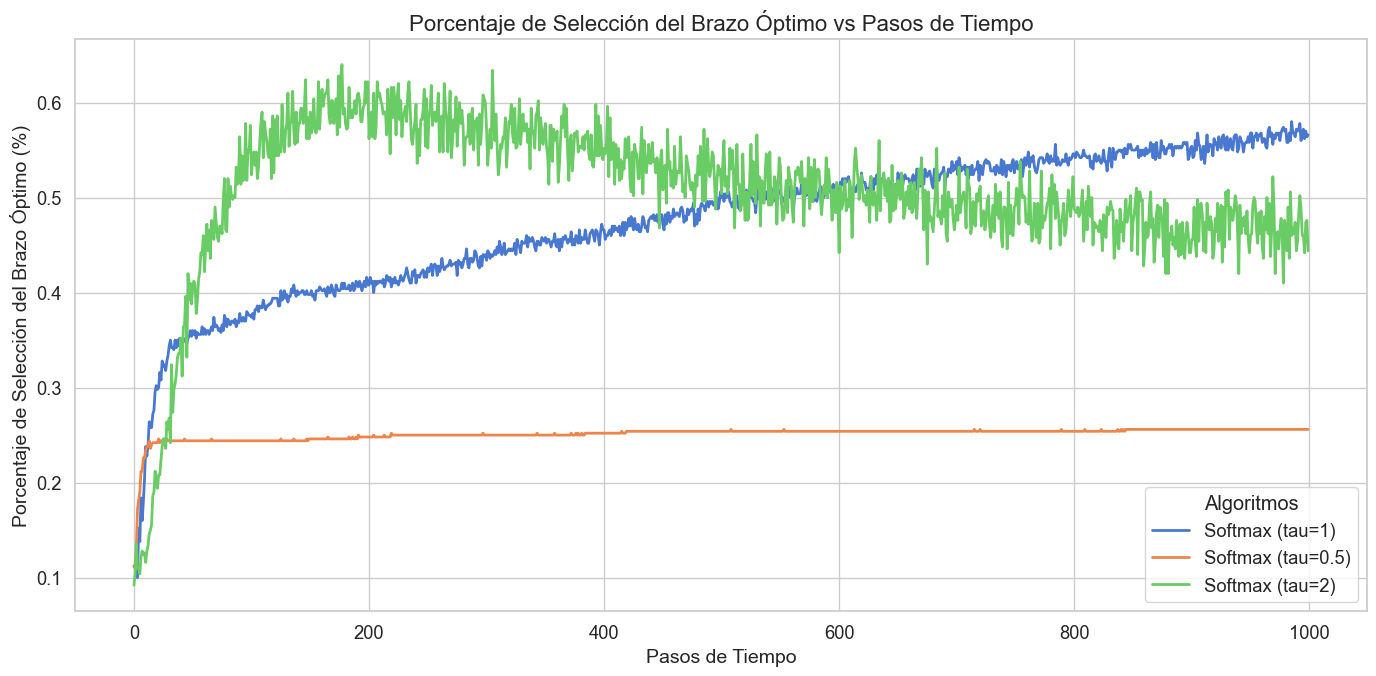

In [7]:
plot_optimal_selections(steps, optimal_selections, algorithms)

En el grafíco anterior podemos apreciar el **Porcentaje de Selección del Brazo Óptimo vs Pasos de Tiempo** aplicado para los algoritmos de Softmax con distintos valores de tau. En este gráfico representamos los steps en comparación con el porcentaje de veces que se selecciona el brazo óptimo.

* **Línea azul (``tau = 1``)**: Al tener un valor de 1 se encuentra en un equilibrio de exploración y explotación. Por lo que irá explorando otras opciones al igual que explota el brazo que considera óptimo. En el gráfico podemos ver que tiene un crecimiento constante durante todos los steps, llegando a aumentar a la línea verde a partir de los 600 steps y seguramente siga creciendo pasados los 1000 steps.

* **Línea naranja (``tau = 0.5``)**: Al tener un valor bajo (tau < 1) favorece más la explotación que la exploración. Es línea es la más baja de todas, pues al parecer está explotando el brazo óptimo equivocado.

* **Línea verde (``tau = 2``)**: Al tener valor alto (tau > 1) favorece más la exploración que la explotación. Esta línea empieza siendo la mejor, a los pocos steps por encima de la azul, pero al llegar a los 200 steps empieza a bajar el número de veces que es seleccionado llegando a los 600 steps a ser menos seleccionada que la línea azul (tau = 1).

##### **1.3 Análisis Histogramas selección de brazos**


Estadísticas de brazos - Softmax (tau=1)
Brazo 1: Recompensa Promedio = 0.4929, Selecciones = 1
Brazo 2: Recompensa Promedio = 0.6134, Selecciones = 2
Brazo 3: Recompensa Promedio = 1.6574, Selecciones = 30
Brazo 4: Recompensa Promedio = 0.9872, Selecciones = 5
Brazo 5: Recompensa Promedio = 2.8899, Selecciones = 184
Brazo 6: Recompensa Promedio = 2.9672, Selecciones = 162
Brazo 7: Recompensa Promedio = 6.1812, Selecciones = 473 (ÓPTIMO)
Brazo 8: Recompensa Promedio = 2.6766, Selecciones = 123
Brazo 9: Recompensa Promedio = 1.2197, Selecciones = 11
Brazo 10: Recompensa Promedio = 0.9056, Selecciones = 4


c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\k-brazos\src\plotting\plotting.py:235: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


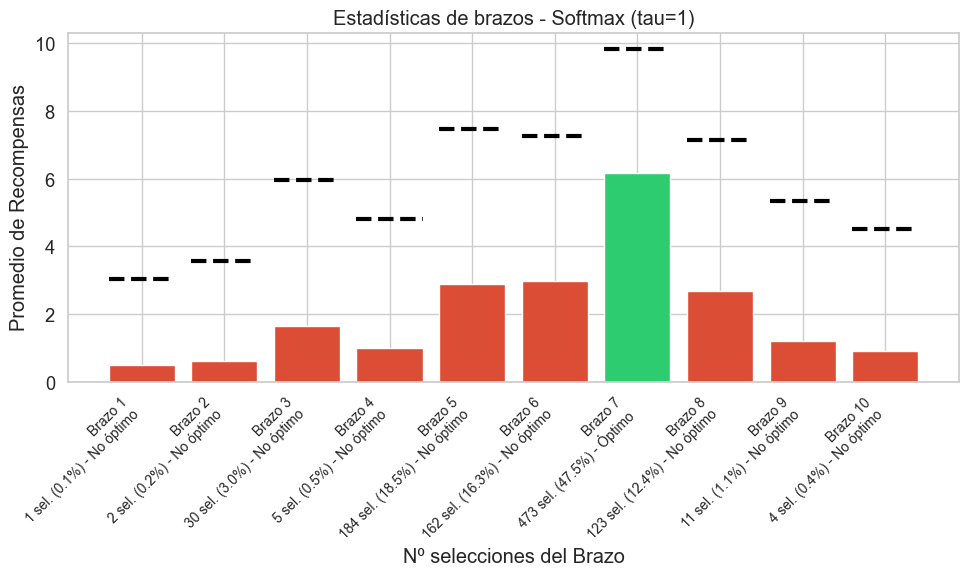

c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\k-brazos\src\plotting\plotting.py:235: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)



Estadísticas de brazos - Softmax (tau=0.5)
Brazo 1: Recompensa Promedio = 0.1634, Selecciones = 1
Brazo 2: Recompensa Promedio = 0.2449, Selecciones = 3
Brazo 3: Recompensa Promedio = 0.9209, Selecciones = 118
Brazo 4: Recompensa Promedio = 0.5824, Selecciones = 58
Brazo 5: Recompensa Promedio = 1.4834, Selecciones = 166
Brazo 6: Recompensa Promedio = 1.3865, Selecciones = 156
Brazo 7: Recompensa Promedio = 2.6513, Selecciones = 250 (ÓPTIMO)
Brazo 8: Recompensa Promedio = 1.2589, Selecciones = 146
Brazo 9: Recompensa Promedio = 0.6696, Selecciones = 75
Brazo 10: Recompensa Promedio = 0.3650, Selecciones = 22


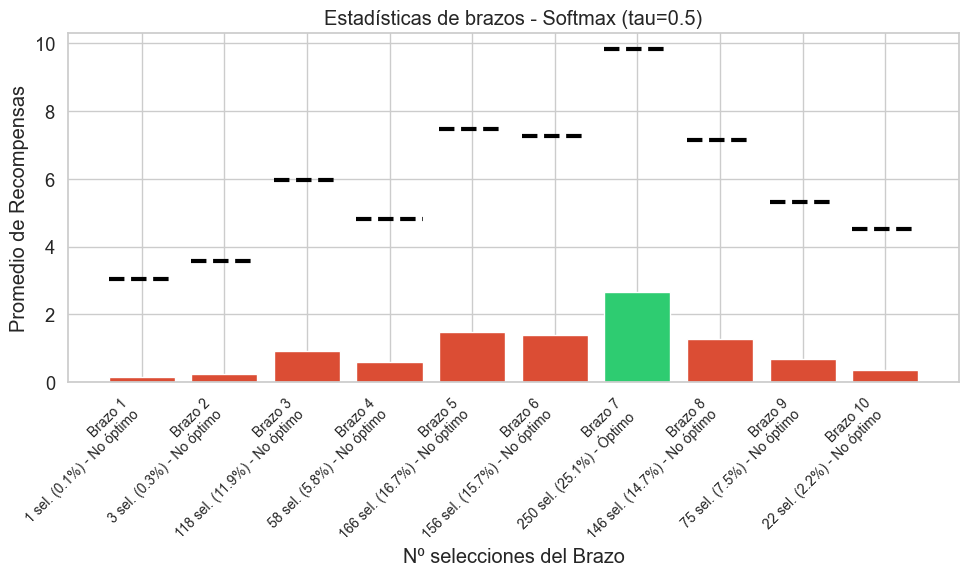

c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\k-brazos\src\plotting\plotting.py:235: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)



Estadísticas de brazos - Softmax (tau=2)
Brazo 1: Recompensa Promedio = 2.0622, Selecciones = 12
Brazo 2: Recompensa Promedio = 2.5607, Selecciones = 15
Brazo 3: Recompensa Promedio = 5.4793, Selecciones = 50
Brazo 4: Recompensa Promedio = 4.0147, Selecciones = 25
Brazo 5: Recompensa Promedio = 7.2938, Selecciones = 126
Brazo 6: Recompensa Promedio = 6.9479, Selecciones = 108
Brazo 7: Recompensa Promedio = 9.8140, Selecciones = 505 (ÓPTIMO)
Brazo 8: Recompensa Promedio = 6.8412, Selecciones = 99
Brazo 9: Recompensa Promedio = 4.7071, Selecciones = 34
Brazo 10: Recompensa Promedio = 3.6196, Selecciones = 21


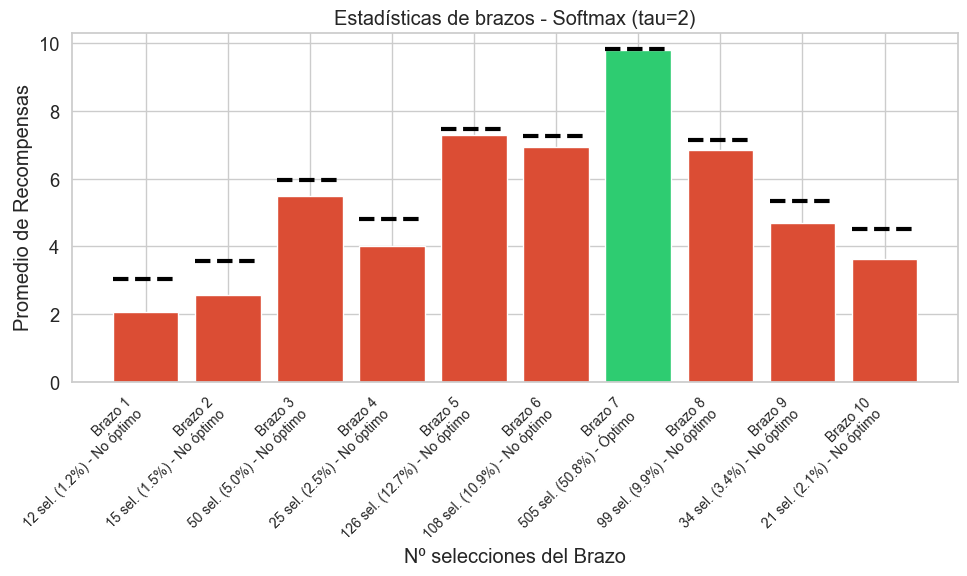

In [8]:
plot_arm_statistics(arm_stats, algorithms, [bandit.get_expected_value(i) for i in range(k)])

Estas tres gráficas muestras los diferentes histográmas de cada algoritmo, mostrándose el **número de veces que ha elegido cada algoritmo a cada brazo del bandido**, además de mostrar la **recompensa promedia** y el brazo óptimo final.

* **Primer histograma (``tau = 1``)**: Con una estrategia igual de exploradora que explotadora y donde podemos apreciar que el brazo 7 ha sido el más seleccionado con 473 selecciones (47.5%) siendo este el brazo óptimo con una recompensa promedio de 6.1812. Por otro lado, tenemos que también se han seleccionado bastantes otros brazos como el 5, 6 y 8 con 185, 162 y 123 selecciones respectivamente.

* **Segundo histograma (``tau = 0.5``)**: Tenemos una estrategia más de explotación y podemos observar en las gráficas que el brazo 7 ha sido el más seleccionado con 250 selecciones (25.1%) siendo este el brazo óptimo con una recompensa promedio de 2.6513. Por otro lado, tenemos que también se han seleccionado bastantes otros brazos como el 5, 6 y 8 con 166, 156 y 146 selecciones respectivamente.

* **Tercer histograma (``tau = 2``)**: Tenemos una estrategia más de exploración y podemos observar en las gráficas que el brazo 7 ha sido el más seleccionado con 505 selecciones (50.8%) siendo este el brazo óptimo con una recompensa promedio de 9.8140. Por otro lado, tenemos que también se han seleccionado bastantes otros brazos como el 5, 6 y 8 con 126, 108 y 99 selecciones respectivamente.

Debemos resaltar las líneas discontinuas que representan el valor óptimo esperado de cada uno de los brazos y que solo se alcanzan con tau = 2, pues con tau = 1 la recompensa promedio tan solo llega a 6 y en tau = 0.5 tan solo a 2.

##### **1.4 Análisis Boxplots de estimaciones de recompensas de cada brazo**

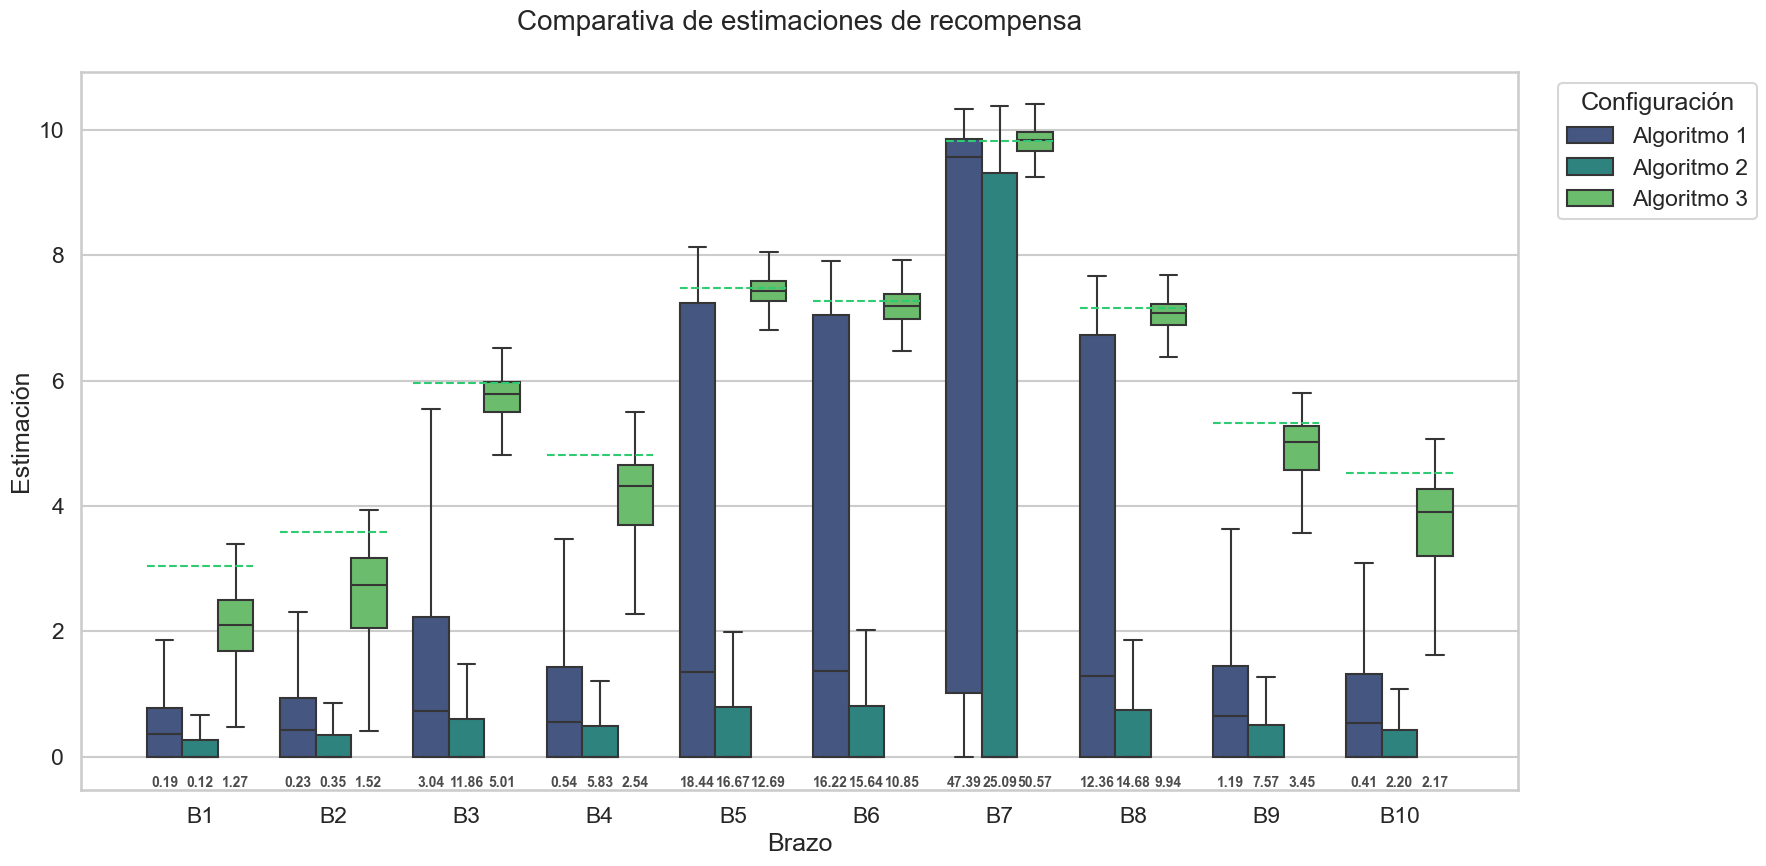

In [9]:
boxplot_estimaciones_brazos(all_runs_data, all_runs_counts, algorithms, [bandit.get_expected_value(i) for i in range(k)])

Esta gráfica muestra los boxplots de las estimaciones de **recompensas promedio según el número de veces que han sido seleccionado** cada brazo. Para cada brazo, se muestra el boxplot para los tres algoritmos, siendo el primero el **Softmax con `tau=1`**, el segundo el **Softmax con `tau=0.5`** y el tercero **Softmax con `tau=2`**, con las estimaciones de las recompensas que el algoritmo cree que tiene cada brazo. Por otro lado, la **línea verde** indica el valor real de recompensa que tiene ese brazo. Por tanto, cuanto más apretada y cercana a la línea verde este, más precisa será la estimación.

* **Algoritmo 1 (Softmax con `tau=1`)**: Para el primer algoritmo, se puede apreciar que los boxplots se dilatan bastante, resaltando el del brazo 7, al igual que el valor real de la recompensa se situa muy lejos de estos, excepto para el brazo 7.
* **Algoritmo 2 (Softmax con `tau=0.5`)**: Para el segundo algoritmo, nos encontramos con una situación similar a la anterior, solo que ahora no se dilatan casi, excepto por el caso del brazo 7.
* **Algoritmo 3 (Softmax con `tau=2`)**: Para el tercer algoritmo, ahora en todos los brazos se consigue un mejor ajuste a los valores reales, debido a que consigue explorar más esos brazos comparado con los otros algoritmos.

Como **conclusiones** de esta gráfica podemos sacar que cuando los dos primeros algoritmos no se acercan a los valores reales de recompensa pues como hemos visto en las gráficas anteriores sobre la selección de brazos con respecto al promedio de recompensa, veíamos como para todos los brazos se alejaban mucho del valores esperado de ellos. Esto solo se conseguía cumplir para el último algoritmo con tau=2 donde casi todos los brazos llegaban a sus valores esperado y el brazo 7 clavándolo.

Finalmente, vamos a pasar a analizar la gráfica del arrepentimiento acomulado.

##### **1.5 Análisis arrepentimiento acumulado**

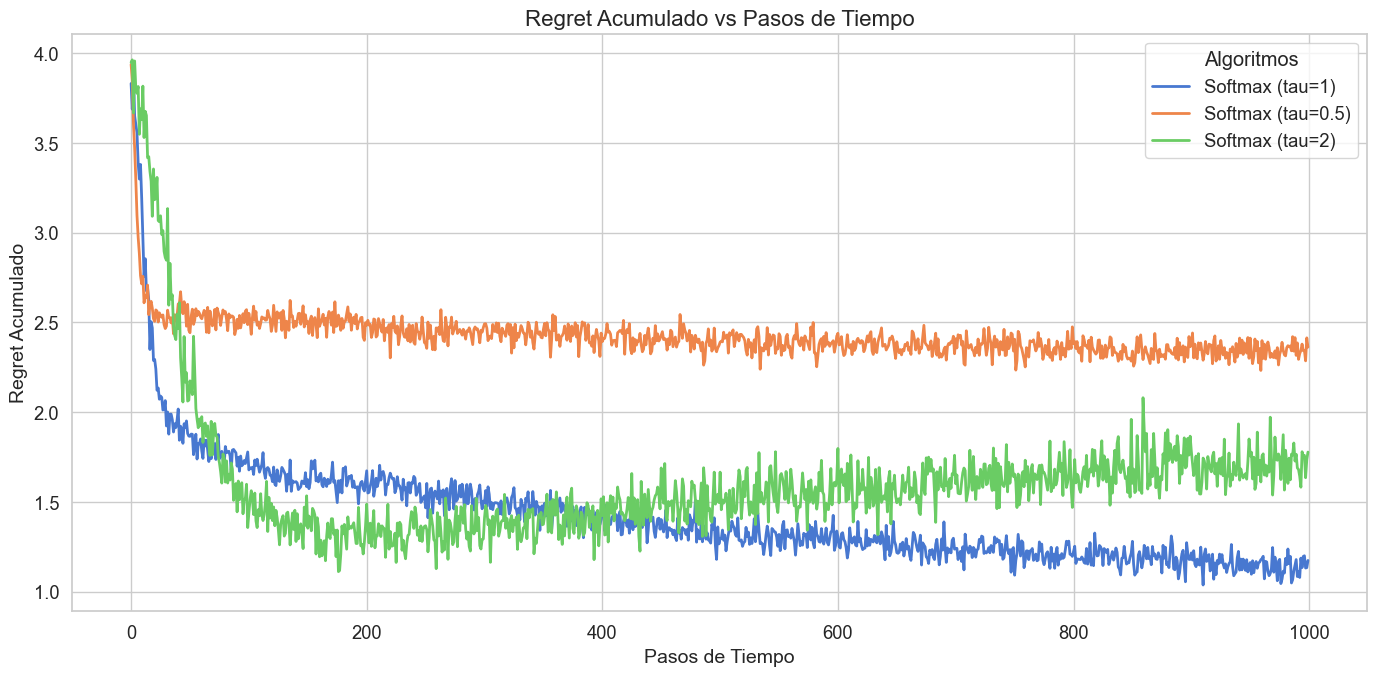

In [10]:
plot_regret(steps, regrets, algorithms)

En el grafíco anterior podemos apreciar el **Arrepentimiento acumulado vs los Steps** aplicado para los algoritmos de Softmax con distintos valores de tau. Donde vemos a simple vista que se trata de las mismas líneas de la gráfica de recompensas promedio pero invertidas.

* **Línea azul (``tau = 1``)**: Al tener un valor de 1 se encuentra en un equilibrio de exploración y explotación. Por lo que irá explorando otras opciones al igual que explota el brazo que considera óptimo. En el gráfico podemos ver que tiene empieza con menor arrepentimiento que la verde, la cual explora más que explota, a partir de los 70 steps acaba superándola en arrepentimiento a la verde hasta los 400 steps donde vuelve a tener menos arrepentimiento que la verde y parece que seguirá teniendo aún menos pasados los 1000 steps.

* **Línea naranja (``tau = 0.5``)**: Al tener un valor bajo (tau < 1) favorece más la explotación que la exploración. Esta línea como no acaba explotando el brazo óptimo su arrepentiemiento es el más grande de todos.

* **Línea verde (``tau = 2``)**: Al tener valor alto (tau > 1) favorece más la exploración que la explotación. Esta línea comienza en los primeros steps siendo la que más arrepentimiento tiene pero al estar explorando más brazos, acaba a los 400 steps teniendo un arrepentimiento mayor que la línea azul.

### ``2. Experimento distribución Bernoulli``

Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución Bernoulli. Se realizan 500 ejecuciones de 1000 pasos cada una. Se contrastan 3 algoritmos de Softmax.

In [11]:
# Creación del bandit
bandit = Bandit(arms=ArmBernoulli.generate_arms(k)) # Generar un bandido con k brazos de distribución de Bernoulli
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [Softmax(k=k, tau=1), Softmax(k=k, tau=0.5), Softmax(k=k, tau=2)]

# Ejecutar el experimento y obtener las recompensas promedio, porcentaje de selecciones óptimas y estadísticas de brazos
rewards, optimal_selections, arm_stats, regrets, all_runs_data, all_runs_counts = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBernoulli(p=0.16), ArmBernoulli(p=0.84), ArmBernoulli(p=0.12), ArmBernoulli(p=0.86), ArmBernoulli(p=0.06), ArmBernoulli(p=0.46), ArmBernoulli(p=0.33), ArmBernoulli(p=0.18), ArmBernoulli(p=0.59), ArmBernoulli(p=0.02)
Optimal arm: 4 with expected reward=0.86


#### **Visualización**

En esta apartado vamos a mostrar y analizar las diferentes gráficas generadas para el experimento del bandido de k-brazos con distribución normal. Las gráficas que se van mostrar son las siguientes:

* Evolución de la recompensa promedio durante el experimento
* Evolución del porcentaje de la selección del mejor brazo
* Número de veces que se ha seleccionado cada brazo en el experimento
* Boxplots de las estimaciones de recompensa por cada brazo.
* Evolución del arrepentimiento durante el experimento

Para empezar, vamos a analizar de la evolución de la recompensa promedio


##### **2.1 Análisis Recompensa promedio**

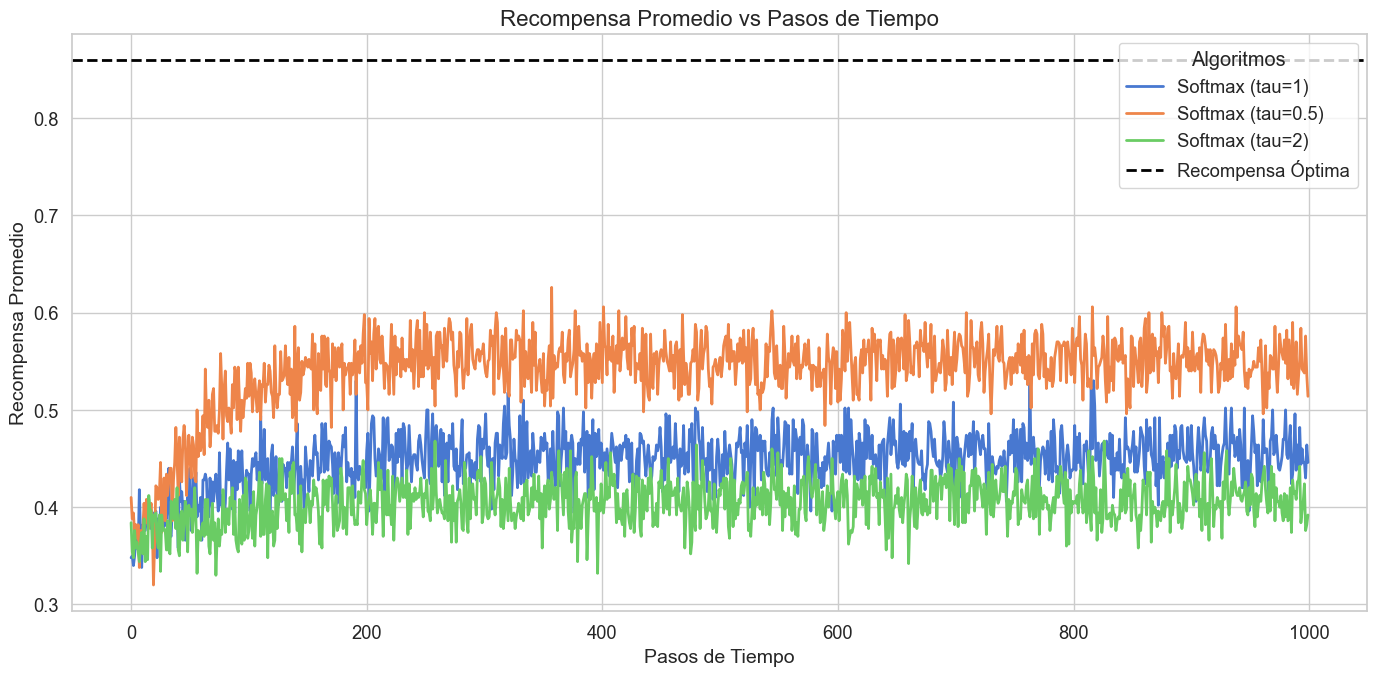

In [12]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms, optimal_reward=bandit.get_expected_value(bandit.optimal_arm))

En el grafíco anterior podemos apreciar la **Recompensa Promedio vs Pasos de Tiempo** aplicado para los algoritmos de Softmax con distintos valores de tau. En este gráfico representamos los steps en comparación con la recompensa promedio que se obtiene. Además, ahora todas las líneas tienen más subidas y bajadas que con la distribución normal, donde las líneas eran más rectas.

En el gráfico podemos ver una gran diferencia con respecto a la distribución normal. Ahora la línea naranja (tau = 0.5) es la que más recompensa promedio obtiene y la verde (tau = 2) la que menos. Además de que todas parecen quedarse esstancadas.

* **Línea discontinua negra**: En esta línea representamos la recompensa óptima que se espera. En concreto sería para el brazo 7 con una recompensa esperada de 0.86.

* **Línea azul (``tau = 1``)**: Al tener un valor de 1 se encuentra en un equilibrio de exploración y explotación. Por lo que irá explorando otras opciones al igual que explota el brazo que considera óptimo. Esta línea se queda como la segunda mejor con una recompensa de 0.45.

* **Línea naranja (``tau = 0.5``)**: Al tener un valor bajo (tau < 1) favorece más explotación que la exploración. Ahora es la línea más alta de todas con unos valores de 0.55 de recompensa promedia.

* **Línea verde (``tau = 2``)**: Al tener valor alto (tau > 1) favorece más exploración que la explotación. Esta línea es la peor de todas con una recompensa promedio de 0.4.

##### **2.2 Análisis Porcentaje selección óptimo**

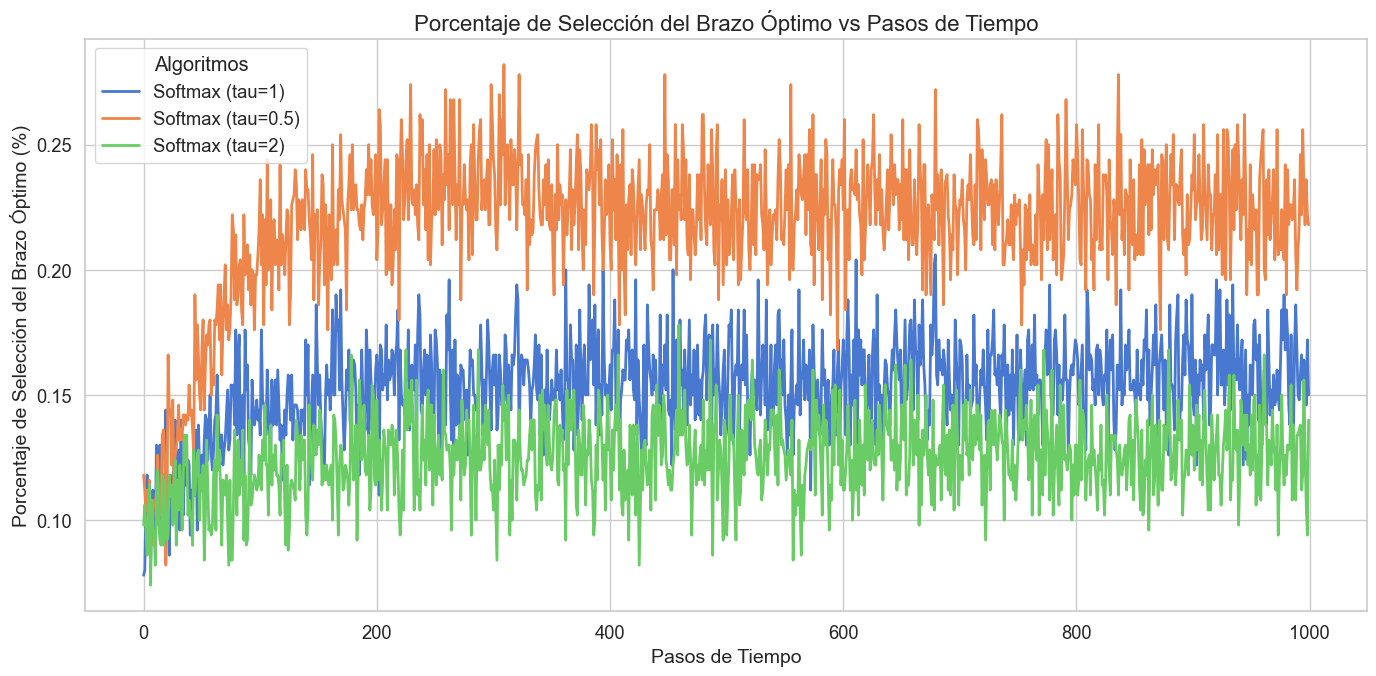

In [13]:
plot_optimal_selections(steps, optimal_selections, algorithms)

En el grafíco anterior podemos apreciar el **Porcentaje de Selección del Brazo Óptimo vs Pasos de Tiempo** aplicado para los algoritmos de Softmax con distintos valores de tau. En este gráfico representamos los steps en comparación con el porcentaje de veces que se selecciona el brazo óptimo.

En el gráfico podemos ver que sigue un mismo orden que en el gráfico de las recompensas promedio.

* **Línea azul (``tau = 1``)**: Al tener un valor de 1 se encuentra en un equilibrio de exploración y explotación. Por lo que irá explorando otras opciones al igual que explota el brazo que considera óptimo. En el gráfico podemos ver que la línea sigue siendo la segunda más seleccionada, por encima de la verde (tau = 2).

* **Línea naranja (``tau = 0.5``)**: Al tener un valor bajo (tau < 1) favorece más la explotación que la exploración. Es línea es la más alta de todas, con una selección alrededor de 0.22.

* **Línea verde (``tau = 2``)**: Al tener valor alto (tau > 1) favorece más la exploración que la explotación. Esta línea es la menos seleccionada de todas, aunque muy de seguido con la línea azul (tau = 1).

Estos resultados llegan hasta el 0.22 de selección, pues como veremos en el siguiente gráfico, el brazo óptimo se acaba seleccionando 218 veces de 1000.

##### **2.3 Análisis Histogramas selección de brazos**


Estadísticas de brazos - Softmax (tau=1)
Brazo 1: Recompensa Promedio = 0.1509, Selecciones = 79
Brazo 2: Recompensa Promedio = 0.8300, Selecciones = 149
Brazo 3: Recompensa Promedio = 0.1160, Selecciones = 77
Brazo 4: Recompensa Promedio = 0.8564, Selecciones = 152 (ÓPTIMO)
Brazo 5: Recompensa Promedio = 0.0547, Selecciones = 73
Brazo 6: Recompensa Promedio = 0.4425, Selecciones = 104
Brazo 7: Recompensa Promedio = 0.3267, Selecciones = 93
Brazo 8: Recompensa Promedio = 0.1765, Selecciones = 79
Brazo 9: Recompensa Promedio = 0.5800, Selecciones = 118
Brazo 10: Recompensa Promedio = 0.0188, Selecciones = 70


c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\k-brazos\src\plotting\plotting.py:235: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


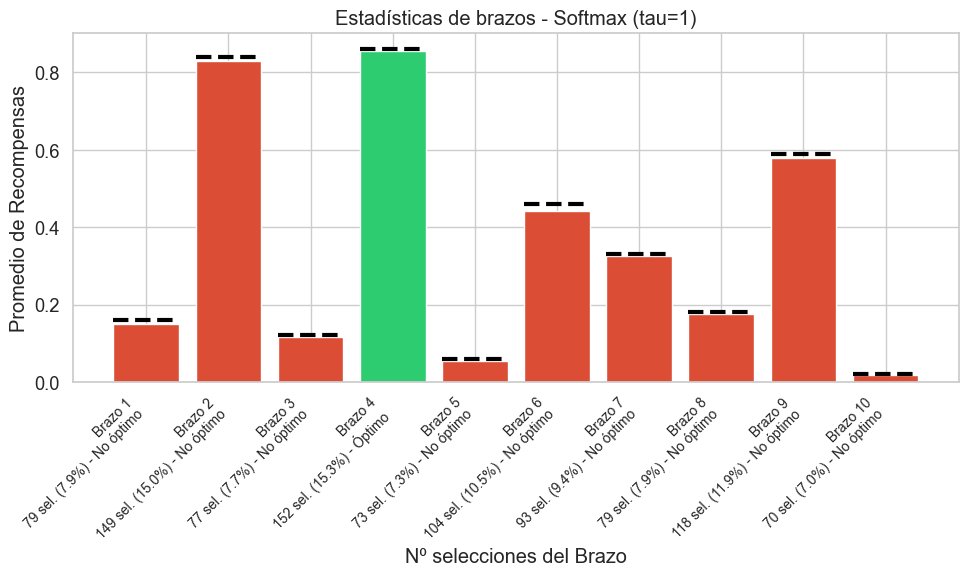

c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\k-brazos\src\plotting\plotting.py:235: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)



Estadísticas de brazos - Softmax (tau=0.5)
Brazo 1: Recompensa Promedio = 0.1456, Selecciones = 58
Brazo 2: Recompensa Promedio = 0.8297, Selecciones = 208
Brazo 3: Recompensa Promedio = 0.1036, Selecciones = 53
Brazo 4: Recompensa Promedio = 0.8501, Selecciones = 218 (ÓPTIMO)
Brazo 5: Recompensa Promedio = 0.0541, Selecciones = 49
Brazo 6: Recompensa Promedio = 0.4301, Selecciones = 98
Brazo 7: Recompensa Promedio = 0.3090, Selecciones = 78
Brazo 8: Recompensa Promedio = 0.1638, Selecciones = 59
Brazo 9: Recompensa Promedio = 0.5653, Selecciones = 127
Brazo 10: Recompensa Promedio = 0.0189, Selecciones = 47


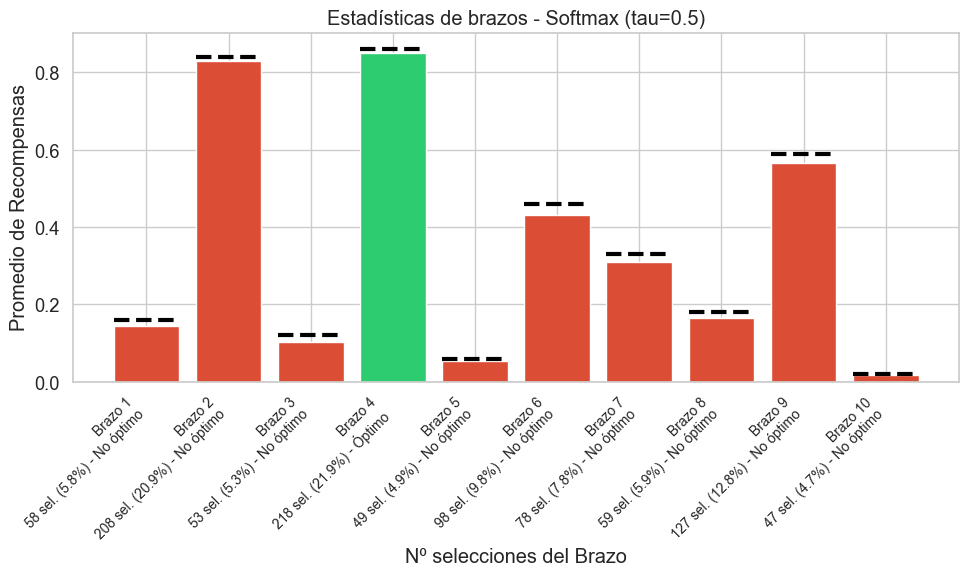


Estadísticas de brazos - Softmax (tau=2)
Brazo 1: Recompensa Promedio = 0.1602, Selecciones = 90
Brazo 2: Recompensa Promedio = 0.8356, Selecciones = 123
Brazo 3: Recompensa Promedio = 0.1194, Selecciones = 88
Brazo 4: Recompensa Promedio = 0.8557, Selecciones = 125 (ÓPTIMO)
Brazo 5: Recompensa Promedio = 0.0557, Selecciones = 86
Brazo 6: Recompensa Promedio = 0.4507, Selecciones = 102
Brazo 7: Recompensa Promedio = 0.3292, Selecciones = 98
Brazo 8: Recompensa Promedio = 0.1725, Selecciones = 90
Brazo 9: Recompensa Promedio = 0.5889, Selecciones = 109
Brazo 10: Recompensa Promedio = 0.0203, Selecciones = 85


c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\k-brazos\src\plotting\plotting.py:235: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


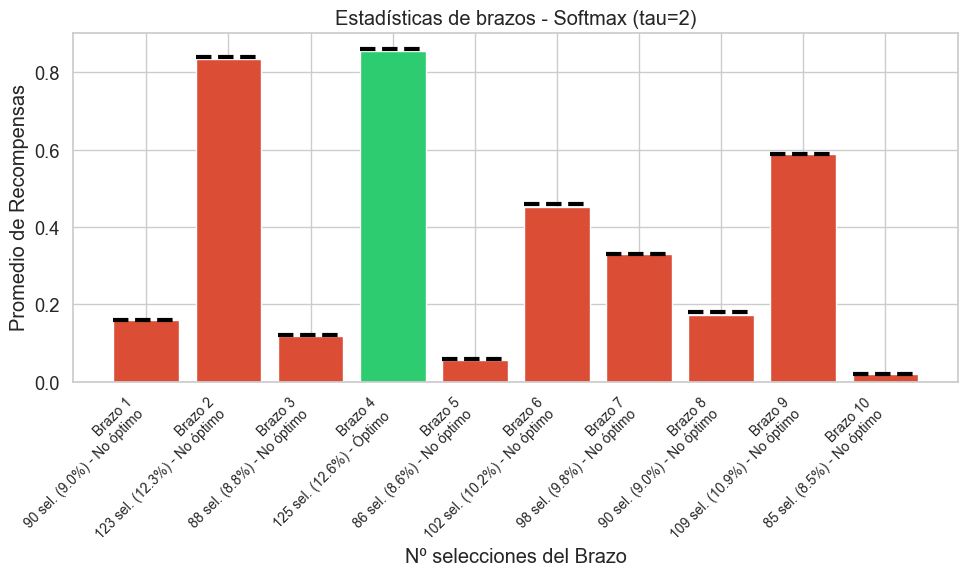

In [14]:
plot_arm_statistics(arm_stats, algorithms,[bandit.get_expected_value(i) for i in range(k)])

Estas tres gráficas muestras los diferentes histográmas de cada algoritmo, mostrándose el **número de veces que ha elegido cada algoritmo a cada brazo** del bandido, además de mostrar la **recompensa promedia** y el brazo óptimo final.

* **Primer histograma (``tau = 1``)**: Con una estrategia igual de exploradora que explotadora y donde podemos apreciar que el brazo 4 ha sido el más seleccionado con 152 selecciones (15.3%) siendo este el brazo óptimo con una recompensa promedio de 0.8564. Por otro lado, tenemos que también se han seleccionado bastentes otros brazos como el 2 con 0.8300 de recompensa promedio y un total de 149 selecciones (15.0%). Prácticamente a la par de selecciones con el 4.

* **Segundo histograma (``tau = 0.5``)**: Tenemos una estrategia más de explotación y podemos observar en las gráficas que el brazo 4 ha sido el más seleccionado con 218 selecciones (21.9%) siendo este el brazo óptimo con una recompensa promedio de 0.8501. Por otro lado, tenemos que también se han seleccionado bastentes otros brazos como el 2 con 0.8297 de recompensa promedio y un total de 208 selecciones (20.9%). Prácticamente a la par de selecciones con el 4.

* **Tercer histograma (``tau = 2``)**: Tenemos una estrategia más de exploración y podemos observar en las gráficas que el brazo 4 ha sido el más seleccionado con 125 selecciones (12.6%) siendo este el brazo óptimo con una recompensa promedio de 0.8557. Por otro lado, tenemos que también se han seleccionado bastentes otros brazos como el 2 con 0.8356 de recompensa promedio y un total de 123 selecciones (12.3%). Con tan solo dos selecciones menos que el brazo óptimo.

Debemos resaltar las líneas discontinuas que representan el valor óptimo esperado de cada uno de los brazos y que donde mejor se alcanzan son con tau = 1 para el brazo óptimo 4.

##### **2.4 Análisis Boxplots de estimaciones de recompensas de cada brazo**

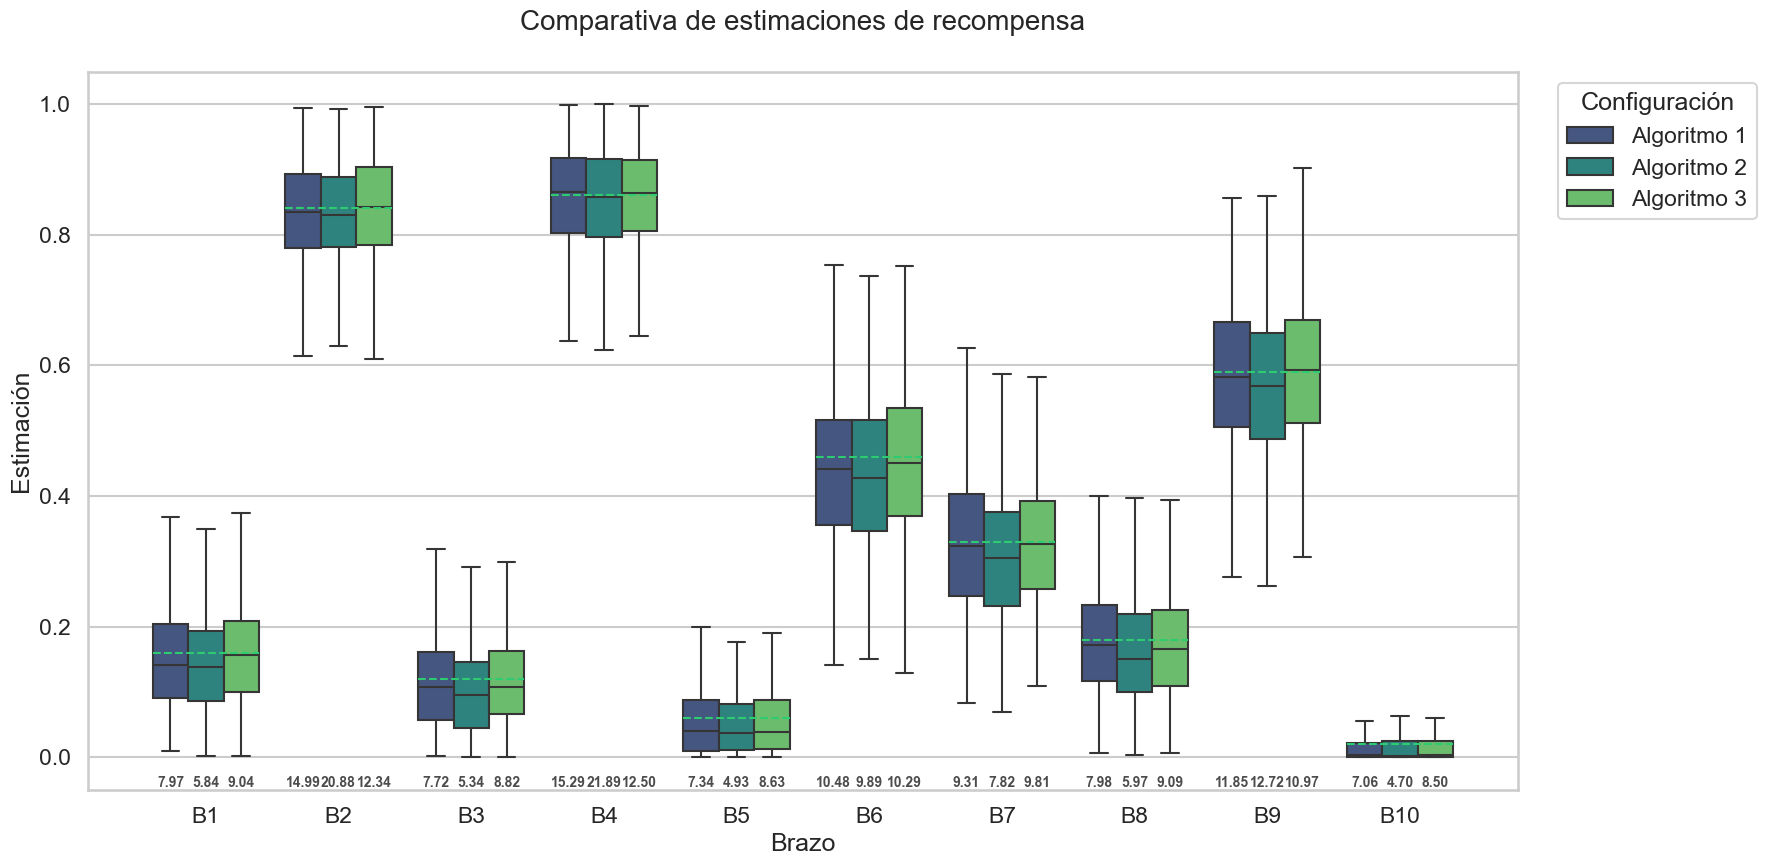

In [15]:
boxplot_estimaciones_brazos(all_runs_data, all_runs_counts, algorithms, [bandit.get_expected_value(i) for i in range(k)])

Esta gráfica muestra los boxplots de las **estimaciones de recompensas promedio según el número de veces que han sido seleccionado cada brazo**. Para cada brazo, se muestra el boxplot para los tres algoritmos, siendo el primero el **Softmax con `tau=1`**, el segundo el **Softmax con `tau=0.5`** y el tercero **Softmax con `tau=2`**, con las estimaciones de las recompensas que el algoritmo cree que tiene cada brazo. Por otro lado, la **línea verde** indica el valor real de recompensa que tiene ese brazo. Por tanto, cuanto más apretada y cercana a la línea verde este, más precisa será la estimación.

* **Algoritmo 1 (Softmax con `tau=1`)**: Para el primer algoritmo, se puede apreciar como en todos los brazos, a excepción del 10, los boxplots se dilatan bastante, aunque el valaor medio de la recompensa se situa cerca del valor real. Esto se debe a que, como se ve debajo, estos brazos no son escogidos muchas veces como vimos anteriormente, dando lugar a no poder visualizar el valor real. 
* **Algoritmo 2 (Softmax con `tau=0.5`)**: Para el segundo algoritmo, nos encontramos con una situación similar a la anterior. Este al ser el algoritmo que explota en mayor medida, no logra seleccionar los brazos óptimos en más ocasiones, ocasionando que la estimación no se ajuste al valor real. Por otro lado, también vemos como se ajusta perfectamente en el brazo 4 al valor real.
* **Algoritmo 3 (Softmax con `tau=2`)**: Para el tercer algoritmo, ahora en todos los brazos se consigue un mejor ajuste a los valores reales, debido a que consigue explorar más esos brazos comparado con los otros algoritmos.

Como **conclusiones** de esta gráfica podemos sacar que se diferencia mucho de los resultados de la distribución normal, pues en esta para todos los algoritmos se consiguen acercar casi todos los brazos a sus valores esperados. Resaltamos el brazo 2 y 4 que consiguen unos valores reales para todos los algorimos.

Finalmente, vamos a pasar a analizar la gráfica del arrepentimiento acomulado.

##### **2.5 Análisis arrepentimiento acumulado**

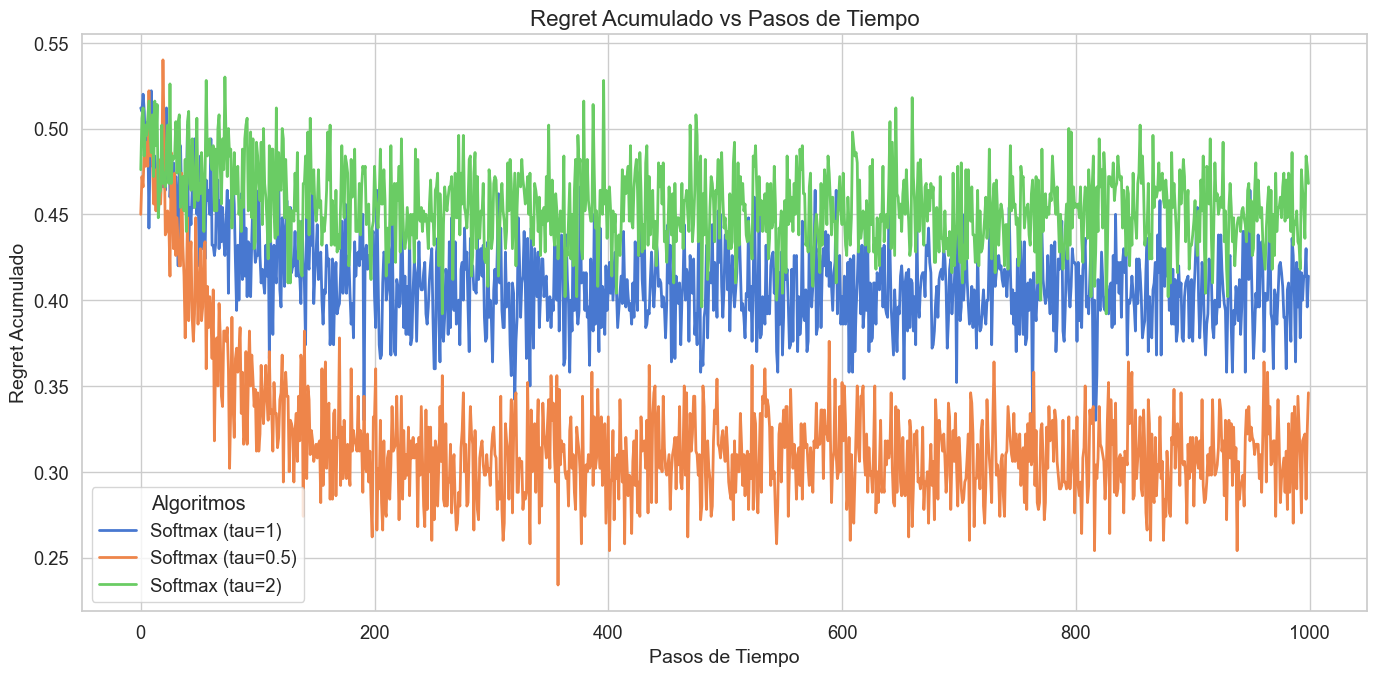

In [16]:
plot_regret(steps, regrets, algorithms)

En el grafíco anterior podemos apreciar el **Arrepentimiento acumulado vs los Steps** aplicado para los algoritmos de Softmax con distintos valores de tau. 

* **Línea azul (``tau = 1``)**: Al tener un valor de 1 se encuentra en un equilibrio de exploración y explotación. Por lo que irá explorando otras opciones al igual que explota el brazo que considera óptimo. En el gráfico podemos ver que la línea empieza con un arrepentimiento igual que el de la línea verde pero consigue reducirlo y estabilizarse siendo la segunda línea con mayor arrepentimiento, tan solo por detrás de la línea verde (tau = 2).

* **Línea naranja (``tau = 0.5``)**: Al tener un valor bajo (tau < 1) favorece más la explotación que la exploración. Esta línea como no acaba explotando el brazo óptimo su arrepentiemiento es el más grande de todos.

* **Línea verde (``tau = 2``)**: Al tener valor alto (tau > 1) favorece más la exploración que la explotación. Esta línea es la que mayor arrepentimiento tiene de todos y tiene sentido al ser la que menor recompensa promedio nos daba y la que menos veces seleccionaba el brazo óptimo.

### ``3. Experimento distribución Binomial``

Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución Binomial. Se realizan 500 ejecuciones de 1000 pasos cada una. Se contrastan 3 algoritmos de Softmax.

In [17]:
# Creación del bandit
bandit = Bandit(arms=ArmBinomial.generate_arms(k)) # Generar un bandido con k brazos de distribución binomial
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [Softmax(k=k, tau=1), Softmax(k=k, tau=0.5), Softmax(k=k, tau=2)]

# Ejecutar el experimento y obtener las recompensas promedio, porcentaje de selecciones óptimas y estadísticas de brazos
rewards, optimal_selections, arm_stats, regrets, all_runs_data, all_runs_counts = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBinomial(n=10, p=0.32), ArmBinomial(n=10, p=0.85), ArmBinomial(n=10, p=0.6), ArmBinomial(n=10, p=0.19), ArmBinomial(n=10, p=0.25), ArmBinomial(n=10, p=0.52), ArmBinomial(n=10, p=0.46), ArmBinomial(n=10, p=0.9), ArmBinomial(n=10, p=0.35), ArmBinomial(n=10, p=0.69)
Optimal arm: 8 with expected reward=9.0


#### **Visualización**

En esta apartado vamos a mostrar y analizar las diferentes gráficas generadas para el experimento del bandido de k-brazos con distribución normal. Las gráficas que se van mostrar son las siguientes:

* Evolución de la recompensa promedio durante el experimento
* Evolución del porcentaje de la selección del mejor brazo
* Número de veces que se ha seleccionado cada brazo en el experimento
* Boxplots de las estimaciones de recompensa por cada brazo.
* Evolución del arrepentimiento durante el experimento

Para empezar, vamos a analizar de la evolución de la recompensa promedio


##### **3.1 Análisis Recompensa promedio**

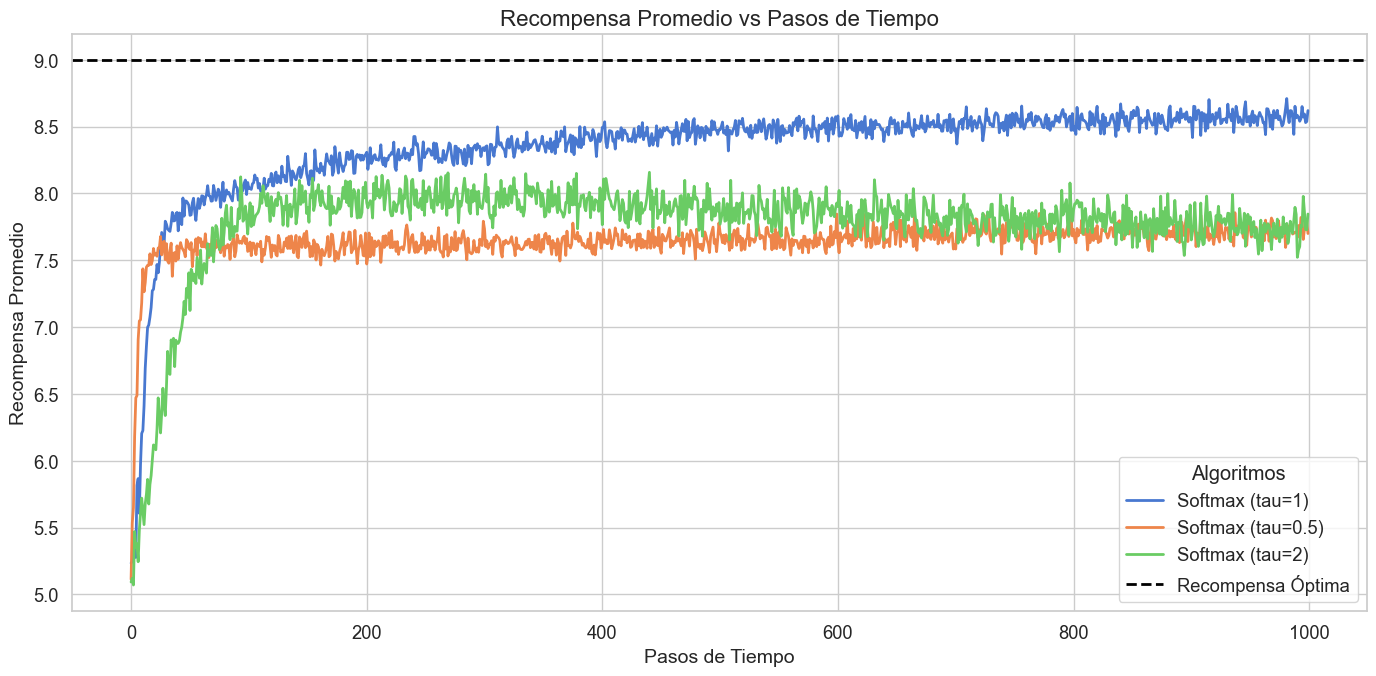

In [18]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms, optimal_reward=bandit.get_expected_value(bandit.optimal_arm))

En el grafíco anterior podemos apreciar la **Recompensa Promedio vs Pasos de Tiempo** aplicado para los algoritmos de Softmax con distintos valores de tau. En este gráfico representamos los steps en comparación con la recompensa promedio que se obtiene.

* **Línea discontinua negra**: En esta línea representamos la recompensa óptima que se espera. En concreto sería para el brazo 8 con una recompensa esperada de 9.0.

* **Línea azul (``tau = 1``)**: Al tener un valor de 1 se encuentra en un equilibrio de exploración y explotación. Por lo que irá explorando otras opciones al igual que explota el brazo que considera óptimo. En el gráfico podemos ver que empieza siendo la segunda que mejor recompensa obtiene y a los 30 steps consigue superar la líena naranja y ser la que mejor recompensa obtiene durante los 1000 steps.

* **Línea naranja (``tau = 0.5``)**: Al tener un valor bajo (tau < 1) favorece más explotación que la exploración. Esta línea empieza siendo la que mejor recompensa tenía, hasta los 70 steps donde se convierte en la más baja de todas, pues al parecer está explotando el brazo óptimo equivocado.

* **Línea verde (``tau = 2``)**: Al tener valor alto (tau > 1) favorece más exploración que la explotación. Esta línea empieza siendo la peor, por debajo de la naranja, pero a los 70 steps consigue superar a la línea naranja aunque consigue llegar a valores de 8 de recompensa, este valor va disminuyendo poco a poco hasta que a los 1000 steps tiene una recompensa similar a la de la línea naranja.

##### **3.2 Análisis Porcentaje selección óptimo**

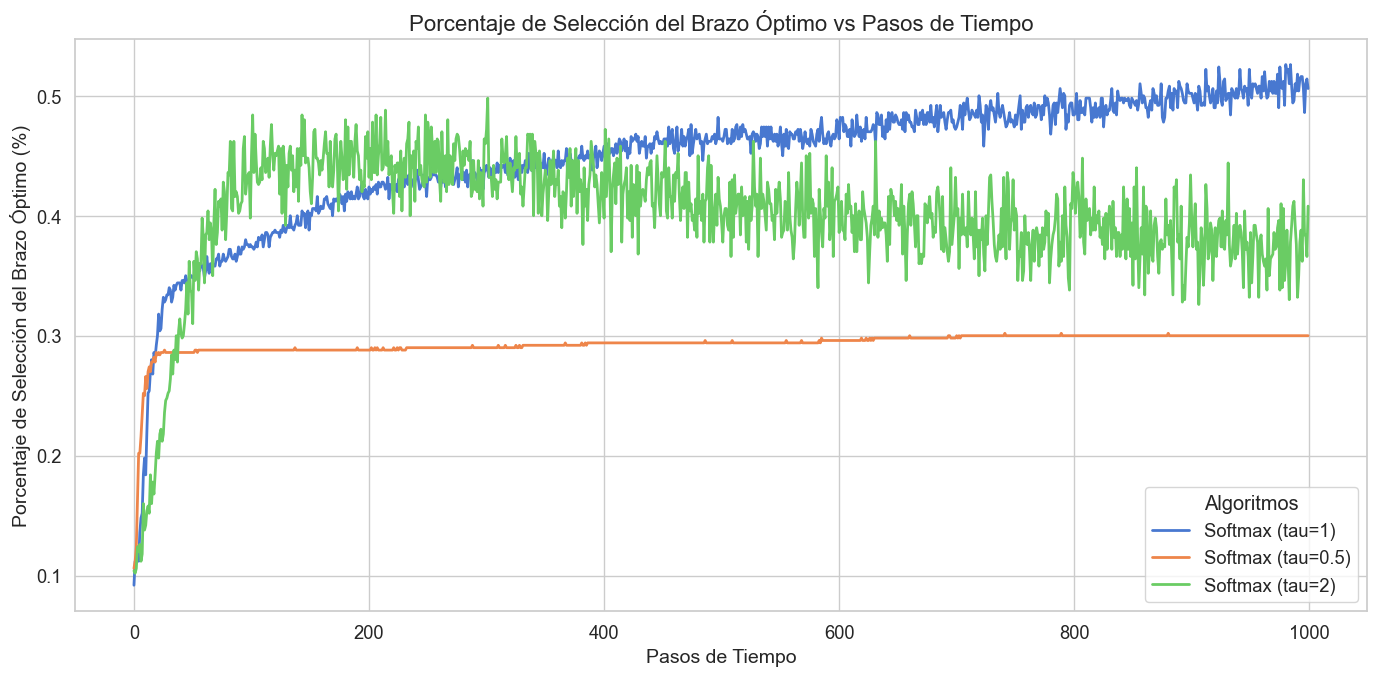

In [19]:
plot_optimal_selections(steps, optimal_selections, algorithms)

En el grafíco anterior podemos apreciar el **Porcentaje de Selección del Brazo Óptimo vs Pasos de Tiempo** aplicado para los algoritmos de Softmax con distintos valores de tau. En este gráfico representamos los steps en comparación con el porcentaje de veces que se selecciona el brazo óptimo.

* **Línea azul (``tau = 1``)**: Al tener un valor de 1 se encuentra en un equilibrio de exploración y explotación. Por lo que irá explorando otras opciones al igual que explota el brazo que considera óptimo. En el gráfico podemos ver que tiene un crecimiento constante durante todos los steps, llegando a aumentar a la línea verde a partir de los 300 steps y seguramente siga creciendo pasados los 1000 steps.

* **Línea naranja (``tau = 0.5``)**: Al tener un valor bajo (tau < 1) favorece más la explotación que la exploración. Es línea es la más baja de todas, pues al parecer está explotando el brazo óptimo equivocado.

* **Línea verde (``tau = 2``)**: Al tener valor alto (tau > 1) favorece más la exploración que la explotación. Esta línea empieza siendo la mejor a partir de los 50 steps, por encima de la azul, pero empieza a disminuir sus números de selección llegando a esstar por debajo de la línea azul a partir de los 300 steps.

Estos resultados llegan hasta el 0.4 de selección para la línea verde de tau = 2 que es la que más recompensa promedio nos obtendrá según el número de selecciones de brazos. El resultado de 0.4 se debe a que como veremos en el siguiente gráfico, el brazo óptimo se acaba seleccionando 400 veces de 1000.

##### **3.3 Análisis Histogramas selección de brazos**


Estadísticas de brazos - Softmax (tau=1)
Brazo 1: Recompensa Promedio = 0.5214, Selecciones = 2
Brazo 2: Recompensa Promedio = 4.5042, Selecciones = 376
Brazo 3: Recompensa Promedio = 1.8743, Selecciones = 38
Brazo 4: Recompensa Promedio = 0.2673, Selecciones = 1
Brazo 5: Recompensa Promedio = 0.3747, Selecciones = 1
Brazo 6: Recompensa Promedio = 1.2949, Selecciones = 11
Brazo 7: Recompensa Promedio = 1.0377, Selecciones = 4
Brazo 8: Recompensa Promedio = 5.4596, Selecciones = 448 (ÓPTIMO)
Brazo 9: Recompensa Promedio = 0.5877, Selecciones = 2
Brazo 10: Recompensa Promedio = 2.3514, Selecciones = 112


c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\k-brazos\src\plotting\plotting.py:235: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


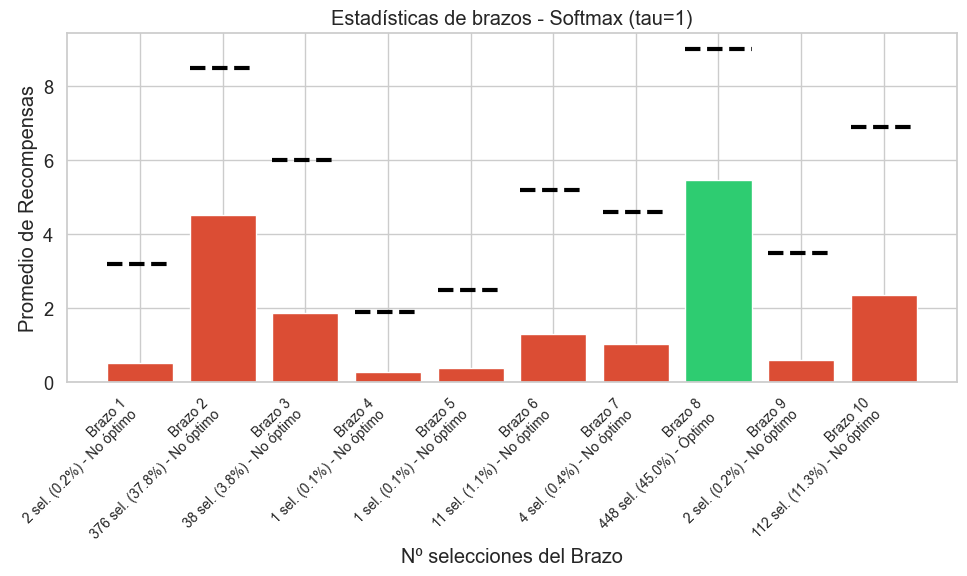

c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\k-brazos\src\plotting\plotting.py:235: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)



Estadísticas de brazos - Softmax (tau=0.5)
Brazo 1: Recompensa Promedio = 0.1892, Selecciones = 1
Brazo 2: Recompensa Promedio = 2.7034, Selecciones = 295
Brazo 3: Recompensa Promedio = 1.0387, Selecciones = 133
Brazo 4: Recompensa Promedio = 0.0926, Selecciones = 0
Brazo 5: Recompensa Promedio = 0.1332, Selecciones = 0
Brazo 6: Recompensa Promedio = 0.5324, Selecciones = 61
Brazo 7: Recompensa Promedio = 0.4549, Selecciones = 40
Brazo 8: Recompensa Promedio = 2.8171, Selecciones = 293 (ÓPTIMO)
Brazo 9: Recompensa Promedio = 0.2256, Selecciones = 5
Brazo 10: Recompensa Promedio = 1.3321, Selecciones = 167


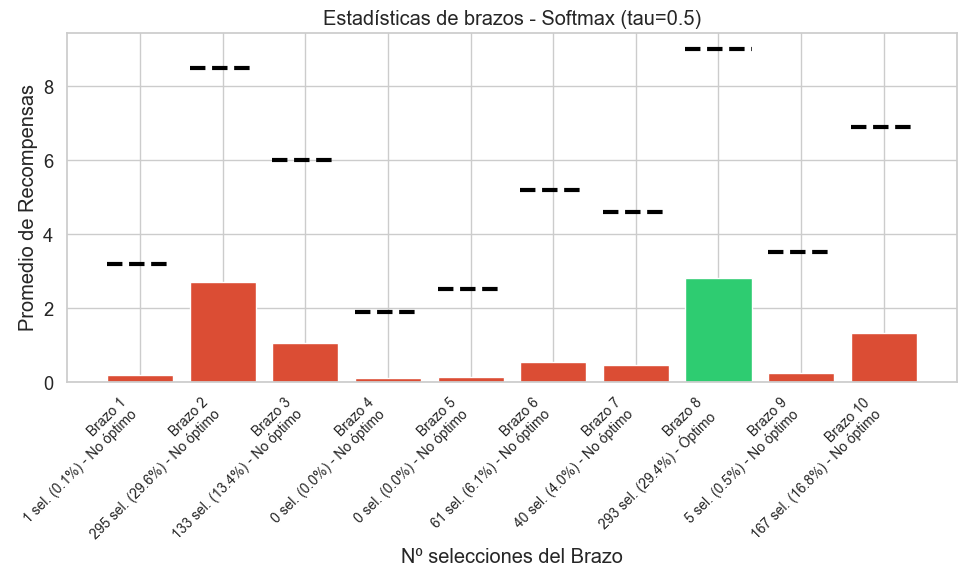


Estadísticas de brazos - Softmax (tau=2)
Brazo 1: Recompensa Promedio = 2.3541, Selecciones = 15
Brazo 2: Recompensa Promedio = 8.4565, Selecciones = 290
Brazo 3: Recompensa Promedio = 5.8103, Selecciones = 68
Brazo 4: Recompensa Promedio = 1.2277, Selecciones = 11
Brazo 5: Recompensa Promedio = 1.7013, Selecciones = 12
Brazo 6: Recompensa Promedio = 4.6823, Selecciones = 40
Brazo 7: Recompensa Promedio = 4.0643, Selecciones = 30
Brazo 8: Recompensa Promedio = 9.0024, Selecciones = 400 (ÓPTIMO)
Brazo 9: Recompensa Promedio = 2.6852, Selecciones = 17
Brazo 10: Recompensa Promedio = 6.7130, Selecciones = 112


c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\k-brazos\src\plotting\plotting.py:235: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


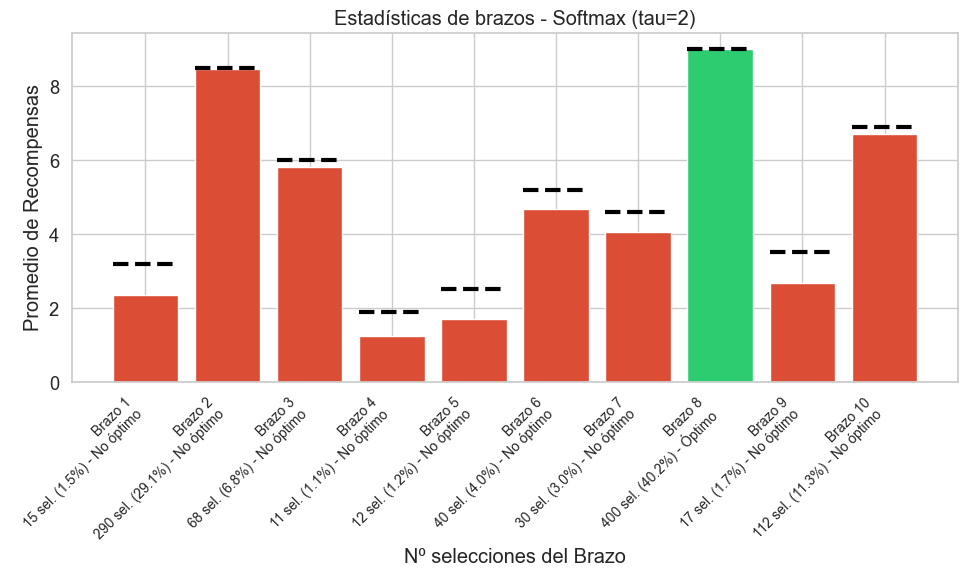

In [20]:
plot_arm_statistics(arm_stats, algorithms,[bandit.get_expected_value(i) for i in range(k)])

Estas tres gráficas muestras los diferentes histográmas de cada algoritmo, mostrándose el **número de veces que ha elegido cada algoritmo a cada brazo** del bandido, además de mostrar la **recompensa promedia** y el brazo óptimo final.

* **Primer histograma (``tau = 1``)**: Con una estrategia igual de exploradora que explotadora y donde podemos apreciar que el brazo 8 ha sido el más seleccionado con 448 selecciones (45.0%) siendo este el brazo óptimo con una recompensa promedio de 5.4596. Por otro lado, tenemos que también se han seleccionado bastentes otros brazos como el 2 con 4.5042 de recompensa promedio y un total de 376 selecciones (37.8%).

* **Segundo histograma (``tau = 0.5``)**: Tenemos una estrategia más de explotación y podemos observar en las gráficas que el brazo 2 ha sido el más seleccionado con 295 selecciones (29.6%) siendo este un brazo no óptimo con una recompensa promedio de 2.7034. Por otro lado, tenemos que el brazo óptimo que debería haber sido el más seleccionado, ha sido seleccionado un total de 293 veces (29.4%) con una recompensa promedio de 2.8171. En este caso un brazo no óptimo ha sido más elegido que el óptimo por 2 selecciones.

* **Tercer histograma (``tau = 2``)**: Tenemos una estrategia más de exploración y podemos observar en las gráficas que el brazo 8 ha sido el más seleccionado con 400 selecciones (40.2%) siendo este el brazo óptimo con una recompensa promedio de 9.0024. Por otro lado, tenemos que también se han seleccionado bastentes otros brazos como el 2 con 8.4565 de recompensa promedio y un total de 290 selecciones (29.1%).

Debemos resaltar las líneas discontinuas que representan el valor óptimo esperado de cada uno de los brazos y que solo se alcanzan con tau = 2, pues con tau = 1 la recompensa promedio tan solo llega a 5 y en tau = 0.5 tan solo a 2.8.

##### **3.4 Análisis Boxplots de estimaciones de recompensas de cada brazo**

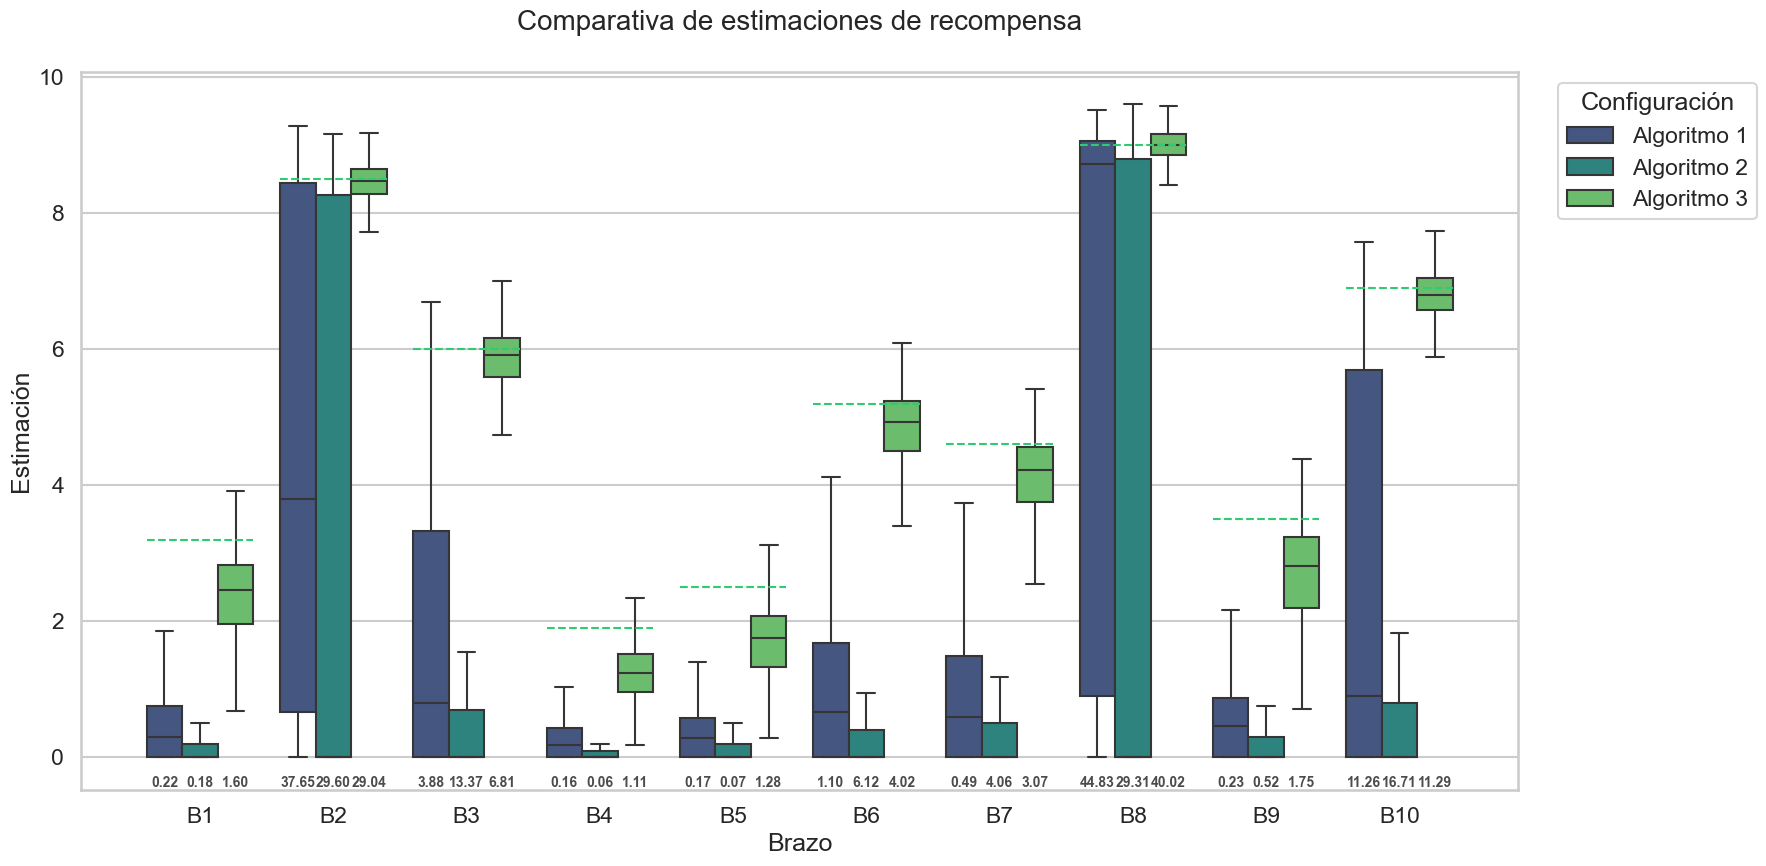

In [21]:
boxplot_estimaciones_brazos(all_runs_data, all_runs_counts, algorithms, [bandit.get_expected_value(i) for i in range(k)])

Esta gráfica muestra los boxplots de las **estimaciones de recompensas promedio según el número de veces que han sido seleccionado cada brazo**. Para cada brazo, se muestra el boxplot para los tres algoritmos, siendo el primero el **Softmax con `tau=1`**, el segundo el **Softmax con `tau=0.5`** y el tercero **Softmax con `tau=2`**, con las estimaciones de las recompensas que el algoritmo cree que tiene cada brazo. Por otro lado, la **línea verde** indica el valor real de recompensa que tiene ese brazo. Por tanto, cuanto más apretada y cercana a la línea verde este, más precisa será la estimación.

* **Algoritmo 1 (Softmax con `tau=1`)**: Para el primer algoritmo, se puede apreciar que los boxplots no se dilatan demasiado a excepción de los brazos 2, 8 y 10 resaltando el de los brazo 2 y 8 pues estos fueron los brazos más seleccionados, al igual que el valor real de la recompensa se situa muy lejos de estos, excepto para el brazo 8.
* **Algoritmo 2 (Softmax con `tau=0.5`)**: Para el segundo algoritmo, nos encontramos con una situación similar a la anterior, excepto que en este solo resaltan los brazos 2 y 8. Además, en todos los brazos, el valor real de la recompensa se situa muy lejos de estos.
* **Algoritmo 3 (Softmax con `tau=2`)**: Para el tercer algoritmo, ahora en todos los brazos se consigue un mejor ajuste a los valores reales, debido a que consigue explorar más esos brazos comparado con los otros algoritmos.

Como **conclusiones** de esta gráfica podemos sacar que los dos primeros algoritmos no se acercan a los valores reales de recompensa pues como hemos visto en las gráficas anteriores sobre la selección de brazos con respecto al promedio de recompensa, veíamos como para todos los brazos se alejaban mucho del valores esperado de ellos. Esto solo se conseguía cumplir para el último algoritmo con tau=2 donde casi todos los brazos llegaban a sus valores esperado y el brazo 8 clavándolo.

Finalmente, vamos a pasar a analizar la gráfica del arrepentimiento acomulado.

##### **3.5 Análisis arrepentimiento acumulado**

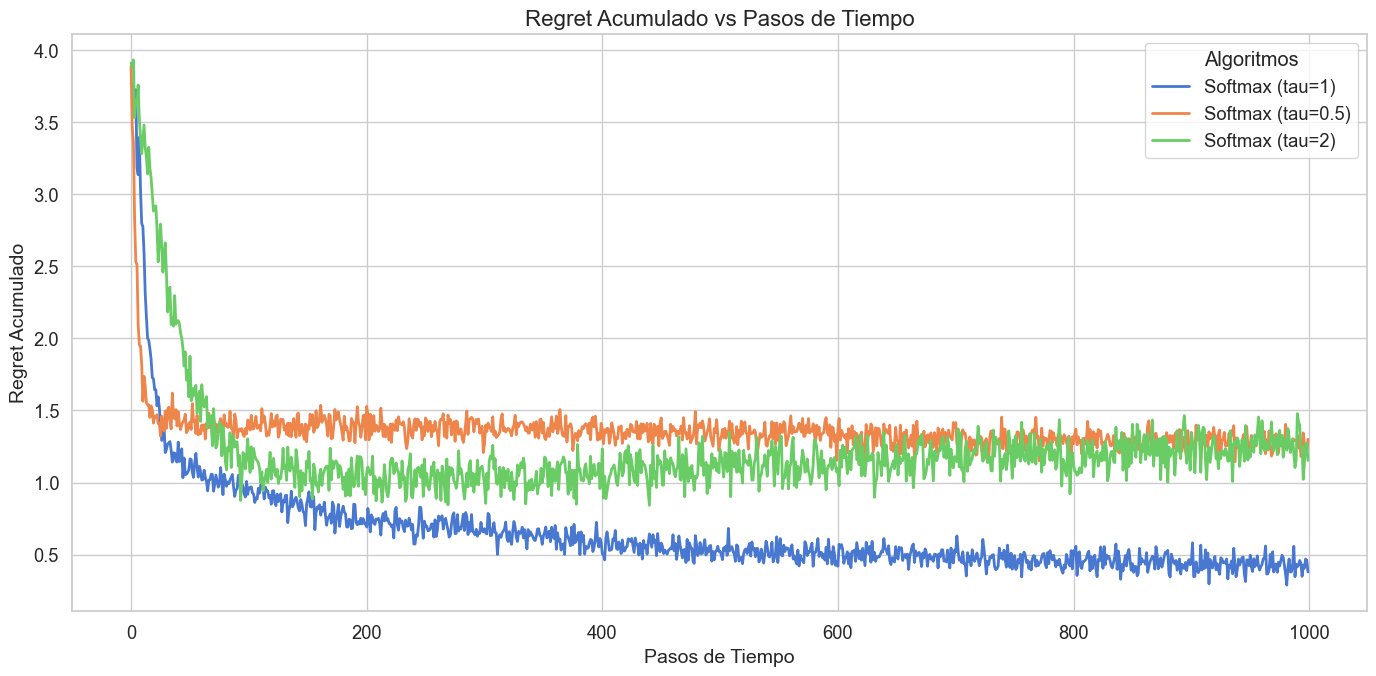

In [22]:
plot_regret(steps, regrets, algorithms)

En el grafíco anterior podemos apreciar el **Arrepentimiento acumulado vs los Steps** aplicado para los algoritmos de Softmax con distintos valores de tau. 

* **Línea azul (``tau = 1``)**: Al tener un valor de 1 se encuentra en un equilibrio de exploración y explotación. Por lo que irá explorando otras opciones al igual que explota el brazo que considera óptimo. En el gráfico podemos ver que la línea empieza con un arrepentimiento mayor que la línea naranja pero consigue reducirlo y es la línea con menos arrepentimiento durante los 1000 steps.

* **Línea naranja (``tau = 0.5``)**: Al tener un valor bajo (tau < 1) favorece más la explotación que la exploración. Esta línea como no acaba explotando el brazo óptimo su arrepentiemiento es el más grande de todos.

* **Línea verde (``tau = 2``)**: Al tener valor alto (tau > 1) favorece más la exploración que la explotación. Esta línea comienza siendo la que más arrepentimiento tiene pero al estar explorando más brazos, se estabiliza sobre 1.2 de arrepentimiento y acaba teniendo más que la línea azul.

## **Conclusiones**

En este estudio hemos analizado el rendimiento del algoritmo de **Softmax** en el contexto del **problema del bandido de k-brazos**, un problema básico dentro del aprendizaje por refuerzo que nos ayuda a entender el funcionamiento de esta disciplina y nos permite comparar el rendimiento de dicho algoritmo utilizando diferentes valores del parámetro ``tau``, además de utilizar diferentes tipos de distribuciones de probabilidad que utiliza el algoritmo para elegir los brazos. Las conclusiones a las que hemos llegado una vez realizado dicho estudio son las siguientes:

1. **Parámetro ``tau``: Exploración frente Explotación**

    En primer lugar, hemos comparado en todos los experimentos la influencia del parámetro ``tau`` en la estimación de la recompensa y la selección del mejor brazo. 
    * Un valor bajo (< 1) del parámetro **``tau``** nos da una **explotación más frecuente y temprana**.
    * Un valor alto (> 1) del parámetro **``tau``** nos da una **exploración de los brazos más prolongada**

    En general, establecer un valor bajo de ``tau`` haciendo una exploración inicial de todos los brazos nos ayuda a poder explotar ese brazo óptimo lo antes posible, obteniendo mejores resultados.

2. **Comparación tipos de distribuciones**

    Acerca de los diferentes tipos de distribuciones, utilizamos tres tipos de distribuciones de probabilidades diferentes, la **normal** que sigue una distribución normal entre dos valores, la **Bernoulli** que representa cada exito de un brazo con 0 o 1, y la **binomial** que generailiza la anterior con exitos de 0 a n. De estos estudios obtenemos lo siguiente:
    * La **distribución normal** es la peor de todas junto a la binomial pues no consiguen estimar bien la recompensa promedio para cuando tau es 0.5 o 1, consiguiendo una buena estimación tan solo para cuando es 2.
    * La **distribución de Bernoulli** es la que mejor se comporta, pues para los tres parámetros de tau probados, consigue una mejor estimación de recompensas promedio con respecto a los de la distribución normal y binomial donde su estimación es floja para cuando tau es 0.5 y 1.
    * La **distribución binomial** se comporta de manera similar a la normal con el mismo caso de que no consigue estimar bien con tau 0.5 o 1. 

3. **Relación selección de brazos frente estimación**
    
    Por otro lado, analizamos cómo se comporta la estimación de la recompensa frente al número de veces que se selecciona un brazo, obteniendo que cuantas más veces se selecciona dicho brazo, más se va ajustando su estimación al valor real. 

4. **Diferencias entre valores de recompensas óptimos**
    Finalmente, nos hemos fijado que el comportamiento de la selección del brazo también influye a la hora de realizar la selección de los brazos. 
    * Cuando el valor de recompensa óptimo es muy alto y alejado del resto permite al algoritmo encontrar dicho valor con mayor velocidad.
    * Cuando el valor de recompensa óptimo está muy cercano a los valores de recompensas de otros brazos, el algoritmo tiende a seleccionarlos aun usando ``tau``=$0.5$, reduciendo el porcentaje de selección del brazo óptimo, aunque la recompensa promedia sea buena.